1 participant(s), 1 run(s), 2 words marked as not understood

test3 · consistent  (2 words, 2 manipulated)
   sentence  1: fondo*, nello*

* = a manipulation rule changed a sound in this word


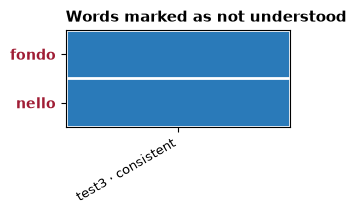

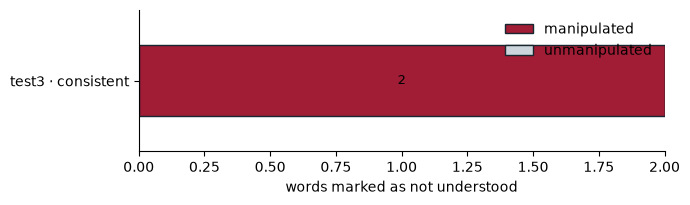

,total,manipulated,unmanipulated
subject,,,
test3 · consistent,2,2,0


wrote marked_words.csv


,participant,version,chunk,word_pos,word,word_clean,altered
2,test3,consistent,1,3,fondo,fondo,1
3,test3,consistent,1,16,nello,nello,1


In [6]:
# === CELL 1 — load ===========================================================
import pandas as pd

CSV = "comprehension_test_result.csv"     # your exported file

raw = pd.read_csv(CSV)

# A sentence is saved again every time someone goes back to it (higher `rev`),
# so keep only the rows of the LAST save of each sentence.
last = raw.groupby(["session", "chunk"])["rev"].transform("max")
raw = raw[raw["rev"] == last]

# Rows with no word = sentences where nothing was marked.
w = raw[raw["word"].notna()].copy()
w["word_pos"] = w["word_pos"].astype(int)
w["altered"]  = w["altered"].fillna(0).astype(int)
w["subject"]  = w["participant"].astype(str) + " · " + w["version"].astype(str)
w = w.sort_values(["participant", "version", "chunk", "word_pos"])

print(f"{w.participant.nunique()} participant(s), {w.subject.nunique()} run(s), "
      f"{len(w)} words marked as not understood")


# === CELL 2 — the words, per subject =========================================
for subj, g in w.groupby("subject"):
    print(f"\n{subj}  ({len(g)} words, {g.altered.sum()} manipulated)")
    for ch, gg in g.groupby("chunk"):
        print(f"   sentence {ch:>2}: " + ", ".join(
            f"{r.word}*" if r.altered else r.word for _, r in gg.iterrows()))
print("\n* = a manipulation rule changed a sound in this word")


# === CELL 3 — visual: the marked words of each subject =======================
from IPython.display import HTML

def word_chips(df):
    out = []
    for subj, g in df.groupby("subject"):
        chips = []
        for _, r in g.iterrows():
            bg, fg = ("#A01D35", "#fff") if r.altered else ("#E3E8EB", "#18262F")
            chips.append(
                f"<span title='sentence {r.chunk}, position {r.word_pos}' "
                f"style='display:inline-block;background:{bg};color:{fg};"
                f"padding:4px 10px;margin:3px;border-radius:7px;font-size:17px'>{r.word}</span>")
        out.append(
            f"<div style='margin:14px 0'>"
            f"<div style='font:600 15px sans-serif;color:#16586E;margin-bottom:4px'>"
            f"{subj} <span style='font-weight:400;color:#7B8892'>— {len(g)} words</span></div>"
            f"<div>{''.join(chips)}</div></div>")
    legend = ("<div style='font:13px sans-serif;color:#586874;margin-bottom:6px'>"
              "<span style='background:#A01D35;color:#fff;padding:2px 7px;border-radius:5px'>red</span>"
              " = word containing a manipulated sound &nbsp;&nbsp;"
              "<span style='background:#E3E8EB;padding:2px 7px;border-radius:5px'>grey</span>"
              " = unmanipulated word</div>")
    return HTML(legend + "".join(out))

word_chips(w)


# === CELL 4 — visual: who marked which word ==================================
import matplotlib.pyplot as plt
import numpy as np

grid = (w.assign(hit=1)
          .pivot_table(index="word_clean", columns="subject", values="hit",
                       aggfunc="max", fill_value=0)
          .sort_index())
alt = w.groupby("word_clean")["altered"].max()   # red label = manipulated in at least one version

fig, ax = plt.subplots(figsize=(1.6 + 1.5 * grid.shape[1], 0.42 * len(grid) + 1.4))
ax.imshow(grid.values, cmap="Blues", vmin=0, vmax=1.4, aspect="auto")
ax.set_xticks(range(grid.shape[1]), grid.columns, rotation=30, ha="right", fontsize=9)
ax.set_yticks(range(len(grid)), grid.index, fontsize=10)
for t, word in zip(ax.get_yticklabels(), grid.index):       # red label = manipulated word
    if alt.get(word, 0):
        t.set_color("#A01D35"); t.set_fontweight("bold")
ax.set_xticks(np.arange(-.5, grid.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-.5, len(grid), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=2)
ax.tick_params(which="minor", length=0)
ax.set_title("Words marked as not understood", loc="left", fontweight="bold", fontsize=11)
plt.tight_layout(); plt.show()


# === CELL 5 — how many words each subject marked =============================
cnt = (w.groupby("subject")["altered"]
         .agg(total="size", manipulated="sum")
         .assign(unmanipulated=lambda d: d.total - d.manipulated)
         .sort_values("total"))

ax = cnt[["manipulated", "unmanipulated"]].plot(
        kind="barh", stacked=True, figsize=(7, 0.55 * len(cnt) + 1.6),
        color=["#A01D35", "#CBD5DB"], edgecolor="#18262F")
ax.set_xlabel("words marked as not understood"); ax.set_ylabel("")
ax.legend(frameon=False); ax.spines[["top", "right"]].set_visible(False)
for c in ax.containers:
    ax.bar_label(c, label_type="center", fontsize=9,
                 labels=[int(v) if v else "" for v in c.datavalues])
plt.tight_layout(); plt.show()

display(cnt)


# === CELL 6 — export =========================================================
out = w[["participant", "version", "chunk", "word_pos", "word", "word_clean", "altered"]]
out.to_csv("marked_words.csv", index=False)
print("wrote marked_words.csv")
display(out)